# Compare Baseline Models — LSTM vs GAT (all 5 datasets)

Evaluates the two new baseline models on all 5 ETH/UCY datasets, computing
**ADE**, **FDE**, **ColRate_avg**, and **ColRate_minADE**.

Social-STGCNN results are already available in `./baseline/`; this notebook
evaluates only **LSTM** and **GAT** trained from scratch via `Colab_Train_Baselines.ipynb`.

**Checkpoint locations** per dataset (must be trained first):
- LSTM: `./baseline_lstm/social-lstm-{dataset}/`
- GAT:  `./baseline_gat/social-gat-{dataset}/`

## 1. Setup

In [1]:
import os
PROJECT_DIR = r'D:\OMSCS\DLproject-Social-STGCNN'
if os.path.isdir(PROJECT_DIR):
    os.chdir(PROJECT_DIR)
print('CWD:', os.getcwd())


CWD: D:\OMSCS\DLproject-Social-STGCNN


In [2]:
import os, pickle
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import torch
import torch.distributions.multivariate_normal as torchdist
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from utils import TrajectoryDataset
from metrics import ade, fde, collision_metrics, seq_to_nodes, nodes_rel_to_nodes_abs
from model_extras import build_model_from_args

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## 2. Configure baselines to compare

In [3]:
DATASETS   = ['eth', 'hotel', 'univ', 'zara1', 'zara2']
KSTEPS     = 20      # Monte Carlo samples per scene
D_COL_EVAL = 0.2     # collision radius (m)

# (display_name, ckpt_dir template with {dataset} placeholder)
MODELS = [
    ('LSTM', './baseline_lstm/social-lstm-{dataset}'),
    ('GAT',  './baseline_gat/social-gat-{dataset}'),
]

print('Checkpoint availability:')
for dataset in DATASETS:
    for name, tmpl in MODELS:
        d = tmpl.format(dataset=dataset)
        exists = os.path.isdir(d)
        print(f'  {name:6s}  {dataset:6s}  {d:50s}  {"OK" if exists else "MISSING"}')

Checkpoint availability:
  LSTM    eth     ./baseline_lstm/social-lstm-eth                     OK
  GAT     eth     ./baseline_gat/social-gat-eth                       OK
  LSTM    hotel   ./baseline_lstm/social-lstm-hotel                   OK
  GAT     hotel   ./baseline_gat/social-gat-hotel                     OK
  LSTM    univ    ./baseline_lstm/social-lstm-univ                    OK
  GAT     univ    ./baseline_gat/social-gat-univ                      OK
  LSTM    zara1   ./baseline_lstm/social-lstm-zara1                   OK
  GAT     zara1   ./baseline_gat/social-gat-zara1                     OK
  LSTM    zara2   ./baseline_lstm/social-lstm-zara2                   OK
  GAT     zara2   ./baseline_gat/social-gat-zara2                     OK


## 3. Data loader helper

In [4]:
def build_test_loader(dataset, obs_len=8, pred_len=12):
    data_root = f'./datasets/{dataset}/'
    dset = TrajectoryDataset(data_root + 'test/', obs_len=obs_len, pred_len=pred_len,
                             skip=1, norm_lap_matr=True)
    loader = DataLoader(dset, batch_size=1, shuffle=False, num_workers=0)
    print(f'  [{dataset}] test set: {len(dset)} scenes')
    return loader

print('build_test_loader() defined.')

build_test_loader() defined.


## 4. Evaluation function

In [5]:
def evaluate_model(ckpt_dir, dataset, ckpt_file='val_best.pth', K=KSTEPS, d_col=D_COL_EVAL):
    ckpt_path = os.path.join(ckpt_dir, ckpt_file)
    if not os.path.exists(ckpt_path):
        print(f'    checkpoint not found: {ckpt_path}')
        return None

    with open(os.path.join(ckpt_dir, 'args.pkl'), 'rb') as f:
        args = pickle.load(f)
    if not hasattr(args, 'model_type'):
        args.model_type = 'stgcnn'

    m = build_model_from_args(args).to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()

    loader_test = build_test_loader(dataset, args.obs_seq_len, args.pred_seq_len)

    ade_ls, fde_ls, col_avg_ls, col_minade_ls = [], [], [], []

    with torch.no_grad():
        for batch in loader_test:
            batch = [t.to(device) for t in batch]
            obs_traj, _, obs_traj_rel, _, _, _, V_obs, A_obs, V_tr, _ = batch
            num_objs = obs_traj_rel.shape[1]

            V_pred, _ = m(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()[:, :num_objs, :]
            V_tr   = V_tr.squeeze()[:, :num_objs, :]

            sx   = torch.exp(V_pred[:,:,2])
            sy   = torch.exp(V_pred[:,:,3])
            corr = torch.tanh(V_pred[:,:,4])
            cov  = torch.zeros(*V_pred.shape[:2], 2, 2, device=device)
            cov[:,:,0,0] = sx*sx;        cov[:,:,0,1] = corr*sx*sy
            cov[:,:,1,0] = corr*sx*sy;   cov[:,:,1,1] = sy*sy
            mvn = torchdist.MultivariateNormal(V_pred[:,:,:2], cov)

            V_x     = seq_to_nodes(obs_traj.cpu().numpy().copy())
            V_x_abs = nodes_rel_to_nodes_abs(
                V_obs.cpu().numpy().squeeze().copy(), V_x[0].copy())
            V_y_abs = nodes_rel_to_nodes_abs(
                V_tr.cpu().numpy().squeeze().copy(), V_x[-1].copy())

            ade_pp = {n: [] for n in range(num_objs)}
            fde_pp = {n: [] for n in range(num_objs)}
            samples_scene = []

            for _ in range(K):
                samp_abs = nodes_rel_to_nodes_abs(
                    mvn.sample().cpu().numpy().squeeze().copy(), V_x[-1].copy())
                samples_scene.append(samp_abs[:, :num_objs, :])
                for n in range(num_objs):
                    ade_pp[n].append(ade([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))
                    fde_pp[n].append(fde([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))

            for n in range(num_objs):
                ade_ls.append(min(ade_pp[n]))
                fde_ls.append(min(fde_pp[n]))

            cm = collision_metrics(samples_scene, V_y_abs[:, :num_objs, :], d_col=d_col)
            col_avg_ls.append(cm['ColRate_avg'])
            col_minade_ls.append(cm['ColRate_minADE'])

    return {
        'ADE':            float(np.mean(ade_ls)),
        'FDE':            float(np.mean(fde_ls)),
        'ColRate_avg':    float(np.mean(col_avg_ls)),
        'ColRate_minADE': float(np.mean(col_minade_ls)),
    }

print('evaluate_model() defined.')

evaluate_model() defined.


## 5. Evaluate LSTM and GAT on all datasets

In [6]:
results = []

for dataset in DATASETS:
    for name, tmpl in MODELS:
        ckpt_dir = tmpl.format(dataset=dataset)
        if not os.path.isdir(ckpt_dir):
            print(f'Skipping {name}/{dataset} — {ckpt_dir} not found')
            continue
        for ckpt_file, ckpt_label in [('val_best.pth', 'val_best'),
                                       ('epoch_final.pth', 'final')]:
            print(f'Evaluating {name} on {dataset} [{ckpt_label}] ...')
            r = evaluate_model(ckpt_dir, dataset, ckpt_file=ckpt_file)
            if r is None:
                continue
            r.update({'Model': name, 'Dataset': dataset, 'Checkpoint': ckpt_label})
            results.append(r)
            print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
                  f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

df = pd.DataFrame(results)[['Model', 'Dataset', 'Checkpoint', 'ADE', 'FDE',
                              'ColRate_avg', 'ColRate_minADE']]
df = df.set_index(['Model', 'Dataset', 'Checkpoint'])
print('\nDone.')

Evaluating LSTM on eth [val_best] ...
Processing Data ..... (70/70)
  [eth] test set: 70 scenes
  ADE=0.7176  FDE=1.2269  ColRate_avg=0.0857  ColRate_minADE=0.1000
Evaluating LSTM on eth [final] ...
Processing Data ..... (70/70)
  [eth] test set: 70 scenes
  ADE=0.7856  FDE=1.4286  ColRate_avg=0.0971  ColRate_minADE=0.1000
Evaluating GAT on eth [val_best] ...
Processing Data ..... (70/70)
  [eth] test set: 70 scenes
  ADE=0.7851  FDE=1.3207  ColRate_avg=0.0750  ColRate_minADE=0.0143
Evaluating GAT on eth [final] ...
Processing Data ..... (70/70)
  [eth] test set: 70 scenes
  ADE=0.7979  FDE=1.3255  ColRate_avg=0.0543  ColRate_minADE=0.0429
Evaluating LSTM on hotel [val_best] ...
Processing Data ..... (301/301)
  [hotel] test set: 301 scenes
  ADE=0.8633  FDE=1.5755  ColRate_avg=0.1638  ColRate_minADE=0.1827
Evaluating LSTM on hotel [final] ...
Processing Data ..... (301/301)
  [hotel] test set: 301 scenes
  ADE=0.8818  FDE=1.6303  ColRate_avg=0.1601  ColRate_minADE=0.1728
Evaluating GA

## 6. Comparison table (val_best checkpoints)

In [7]:
df_best = df.xs('val_best', level='Checkpoint')   # (Model, Dataset) index

fmt = {'ADE':'{:.4f}', 'FDE':'{:.4f}',
       'ColRate_avg':'{:.4f}', 'ColRate_minADE':'{:.4f}'}
styled = (df_best.style
    .format(fmt)
    .background_gradient(subset=['ADE'],         cmap='RdYlGn_r')
    .background_gradient(subset=['FDE'],         cmap='RdYlGn_r')
    .background_gradient(subset=['ColRate_avg'], cmap='RdYlGn_r')
    .set_caption('LSTM vs GAT — val_best checkpoints, all datasets'))
display(styled)

,,ADE,FDE,ColRate_avg,ColRate_minADE
Model,Dataset,,,,
LSTM,eth,0.7176,1.2269,0.0857,0.1000
GAT,eth,0.7851,1.3207,0.0750,0.0143
LSTM,hotel,0.8633,1.5755,0.1638,0.1827
GAT,hotel,0.4567,0.8879,0.1412,0.1395
LSTM,univ,0.4926,0.8365,0.9051,0.9018
GAT,univ,0.4305,0.7894,0.8676,0.8754
LSTM,zara1,0.3692,0.5707,0.1849,0.1761
GAT,zara1,0.3061,0.5170,0.1278,0.0963
LSTM,zara2,0.3212,0.4402,0.5302,0.5451


## 7. Grouped bar chart — LSTM vs GAT per dataset

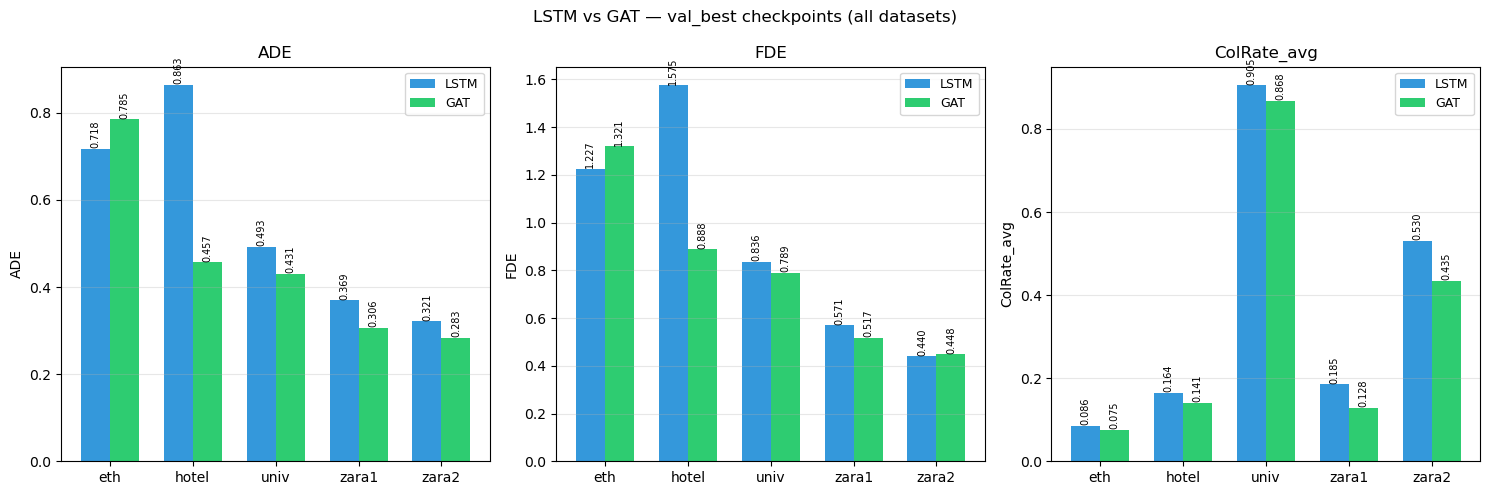

Saved baselines_lstm_gat_comparison.png


In [8]:
metrics_to_plot = ['ADE', 'FDE', 'ColRate_avg']
model_names = [name for name, _ in MODELS]
colors = {'LSTM': '#3498db', 'GAT': '#2ecc71'}
x = np.arange(len(DATASETS))
width = 0.35

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 5))

for ax, metric in zip(axes, metrics_to_plot):
    for i, model_name in enumerate(model_names):
        vals = []
        for ds in DATASETS:
            try:
                vals.append(df_best.loc[(model_name, ds), metric])
            except KeyError:
                vals.append(float('nan'))
        offset = (i - (len(model_names) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=model_name,
                      color=colors.get(model_name, '#e74c3c'))
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}',
                        ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('LSTM vs GAT — val_best checkpoints (all datasets)', fontsize=12)
plt.tight_layout()
plt.savefig('baselines_lstm_gat_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved baselines_lstm_gat_comparison.png')

## 8. Save CSV

In [9]:
df.to_csv('baselines_lstm_gat_comparison.csv')
print('Saved baselines_lstm_gat_comparison.csv')
display(df)

Saved baselines_lstm_gat_comparison.csv


ADE       FDE  ColRate_avg  ColRate_minADE
Model Dataset Checkpoint                                                 
LSTM  eth     val_best    0.717597  1.226866     0.085714        0.100000
              final       0.785608  1.428593     0.097143        0.100000
GAT   eth     val_best    0.785052  1.320664     0.075000        0.014286
              final       0.797909  1.325478     0.054286        0.042857
LSTM  hotel   val_best    0.863280  1.575476     0.163787        0.182724
              final       0.881812  1.630317     0.160133        0.172757
GAT   hotel   val_best    0.456652  0.887878     0.141196        0.139535
              final       0.453295  0.873982     0.140365        0.136213
LSTM  univ    val_best    0.492581  0.836488     0.905069        0.901795
              final       0.637467  1.276898     0.902112        0.901795
GAT   univ    val_best    0.430540  0.789355     0.867582        0.875396
              final       0.417760  0.746863     0.877614        0.872228
LSTM  zara1   val_best    0.369231  0.570700     0.184884        0.176080
              final       0.771990  1.622019     0.193522        0.202658
GAT   zara1   val_best    0.306052  0.517037     0.127824        0.096346
              final       0.367950  0.670532     0.141860        0.119601
LSTM  zara2   val_best    0.321225  0.440205     0.530185        0.545060
              final       0.321170  0.441506     0.527470        0.536374
GAT   zara2   val_best    0.282970  0.447865     0.434962        0.418024
              final       0.289338  0.460764     0.449403        0.436482

In [10]:
print(df)

                               ADE       FDE  ColRate_avg  ColRate_minADE
Model Dataset Checkpoint                                                 
LSTM  eth     val_best    0.717597  1.226866     0.085714        0.100000
              final       0.785608  1.428593     0.097143        0.100000
GAT   eth     val_best    0.785052  1.320664     0.075000        0.014286
              final       0.797909  1.325478     0.054286        0.042857
LSTM  hotel   val_best    0.863280  1.575476     0.163787        0.182724
              final       0.881812  1.630317     0.160133        0.172757
GAT   hotel   val_best    0.456652  0.887878     0.141196        0.139535
              final       0.453295  0.873982     0.140365        0.136213
LSTM  univ    val_best    0.492581  0.836488     0.905069        0.901795
              final       0.637467  1.276898     0.902112        0.901795
GAT   univ    val_best    0.430540  0.789355     0.867582        0.875396
              final       0.417760  0.

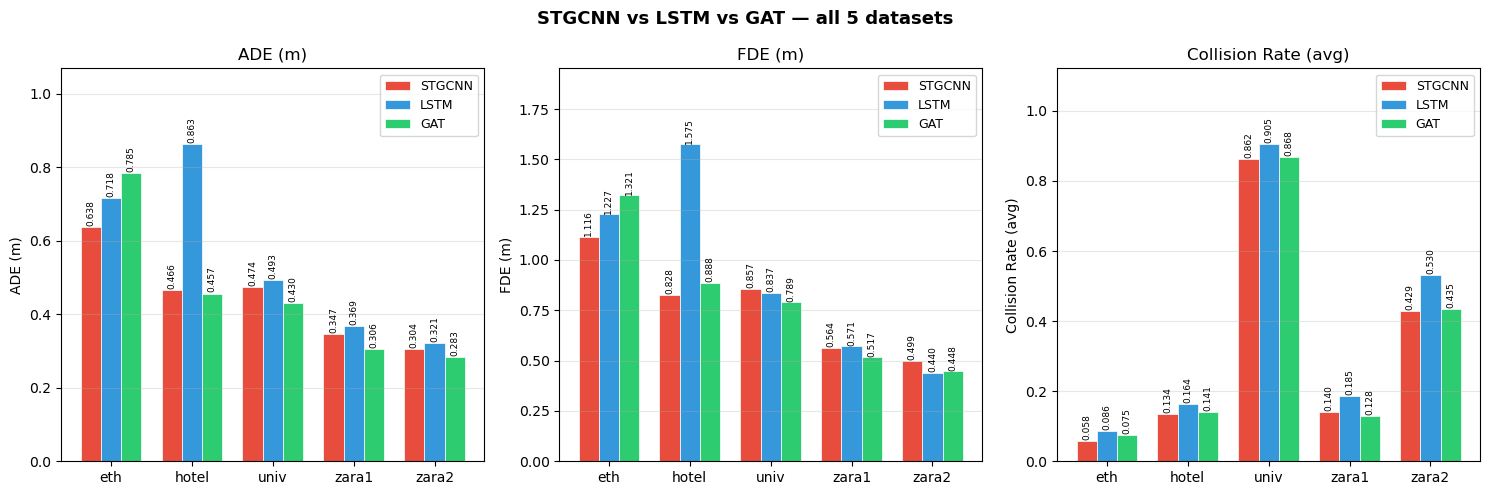

Saved baselines_3model_comparison.png


In [1]:

# ── 3-model comparison: STGCNN vs LSTM vs GAT ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASETS = ['eth', 'hotel', 'univ', 'zara1', 'zara2']

all_rows = [
    # STGCNN (250 epochs, baseline loss)
    {'Model': 'STGCNN', 'Dataset': 'eth',   'ADE': 0.6376, 'FDE': 1.1157, 'ColRate_avg': 0.0579},
    {'Model': 'STGCNN', 'Dataset': 'hotel', 'ADE': 0.4657, 'FDE': 0.8282, 'ColRate_avg': 0.1342},
    {'Model': 'STGCNN', 'Dataset': 'univ',  'ADE': 0.4740, 'FDE': 0.8574, 'ColRate_avg': 0.8624},
    {'Model': 'STGCNN', 'Dataset': 'zara1', 'ADE': 0.3474, 'FDE': 0.5639, 'ColRate_avg': 0.1395},
    {'Model': 'STGCNN', 'Dataset': 'zara2', 'ADE': 0.3045, 'FDE': 0.4986, 'ColRate_avg': 0.4294},
    # LSTM (100 epochs, val_best)
    {'Model': 'LSTM',   'Dataset': 'eth',   'ADE': 0.7176, 'FDE': 1.2269, 'ColRate_avg': 0.0857},
    {'Model': 'LSTM',   'Dataset': 'hotel', 'ADE': 0.8633, 'FDE': 1.5755, 'ColRate_avg': 0.1638},
    {'Model': 'LSTM',   'Dataset': 'univ',  'ADE': 0.4926, 'FDE': 0.8365, 'ColRate_avg': 0.9051},
    {'Model': 'LSTM',   'Dataset': 'zara1', 'ADE': 0.3692, 'FDE': 0.5707, 'ColRate_avg': 0.1849},
    {'Model': 'LSTM',   'Dataset': 'zara2', 'ADE': 0.3212, 'FDE': 0.4402, 'ColRate_avg': 0.5302},
    # GAT (100 epochs, val_best)
    {'Model': 'GAT',    'Dataset': 'eth',   'ADE': 0.7851, 'FDE': 1.3207, 'ColRate_avg': 0.0750},
    {'Model': 'GAT',    'Dataset': 'hotel', 'ADE': 0.4567, 'FDE': 0.8879, 'ColRate_avg': 0.1412},
    {'Model': 'GAT',    'Dataset': 'univ',  'ADE': 0.4305, 'FDE': 0.7894, 'ColRate_avg': 0.8676},
    {'Model': 'GAT',    'Dataset': 'zara1', 'ADE': 0.3061, 'FDE': 0.5170, 'ColRate_avg': 0.1278},
    {'Model': 'GAT',    'Dataset': 'zara2', 'ADE': 0.2830, 'FDE': 0.4479, 'ColRate_avg': 0.4350},
]

df_all = pd.DataFrame(all_rows)

MODEL_ORDER   = ['STGCNN', 'LSTM', 'GAT']
METRICS       = ['ADE', 'FDE', 'ColRate_avg']
METRIC_LABELS = {'ADE': 'ADE (m)', 'FDE': 'FDE (m)', 'ColRate_avg': 'Collision Rate (avg)'}
COLORS        = {'STGCNN': '#e74c3c', 'LSTM': '#3498db', 'GAT': '#2ecc71'}

x     = np.arange(len(DATASETS))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, METRICS):
    for i, model in enumerate(MODEL_ORDER):
        vals = [
            df_all.loc[(df_all.Model == model) & (df_all.Dataset == ds), metric].values[0]
            if len(df_all.loc[(df_all.Model == model) & (df_all.Dataset == ds)]) else float('nan')
            for ds in DATASETS
        ]
        offset = (i - 1) * width
        bars = ax.bar(x + offset, vals, width, label=model,
                      color=COLORS[model], edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS, fontsize=10)
    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)

fig.suptitle('STGCNN vs LSTM vs GAT — all 5 datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baselines_3model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved baselines_3model_comparison.png')
